# 📘 Lecture 4: Machine Learning Datasets, Discrete Preprocessing, Text Vectorization, Missingness Mechanisms & AI Alignment
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 4 - YouTube](https://youtu.be/UmSuBvK6u3I?si=woocB4dRYeIXd3Jh)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we bridge the gap between abstract mathematical models and real-world data pipelines. A model is only as good as the data fed into it ("Garbage In, Garbage Out"). We cover:
1. **Benchmark Datasets & Metric Evaluation**: Small image datasets (MNIST, EMNIST, Fashion-MNIST, CIFAR-10), large scale vision (ImageNet ILSVRC, Top-5 Error Rate math), and NLP tasks (IMDb, WMT, Europarl).
2. **Discrete & Categorical Preprocessing**: One-Hot Encoding math, High-Cardinality variables, and Feature Crosses to capture nonlinear feature interactions.
3. **Text Data Preprocessing & Document Vectorization**: Challenges with text (variable length, categorical words, Out-of-Vocabulary OOV), Bag-of-Words (BoW), Term Frequency (TF), and Inverse Document Frequency (TF-IDF) with sublinear log scaling.
4. **Word Embeddings & Bag-of-Word Embeddings**: Vector space similarity ($\cos\theta$), mapping to low-dimensional continuous space $\mathbf{E} \in \mathbb{R}^{K \times |V|}$, linear parameter estimation in Logistic Regression, and Subword Tokenization (BPE/WordPiece).
5. **Missingness Mechanisms (Rubin's Framework)**: Formal math for Missing Completely at Random (MCAR), Missing at Random (MAR), and Missing Not at Random (MNAR), alongside Mean Imputation and Generative Imputation.
6. **AI Alignment, Reward Hacking & Inverse RL**: The Alignment Problem, reward specification traps, Inverse Reinforcement Learning (Stuart Russell), and AGI vs Augmented Intelligence.

---


## 0️⃣ Environment Setup & Imports
We start by importing standard scientific, machine learning, and visualization libraries.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.impute import SimpleImputer

# Set seed for complete reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ Libraries imported successfully! PyTorch Version:", torch.__version__)


✅ Libraries imported successfully! PyTorch Version: 2.11.0+cpu


## 1️⃣ Machine Learning Benchmarks & Top-5 Error Metrics

### 1.1 Vision Benchmarks: From Small-Scale to ImageNet
- **MNIST**: 60,000 training, 10,000 test $28 \times 28$ grayscale images across 10 digit classes ($0-9$). Pixel values $x_{i,j} \in [0, 255]$ are normalized to $[0, 1]$ or standardized to $\mu=0, \sigma=1$. Binarization via thresholding:
  $$\tilde{x}_{i,j} = \mathbb{I}(x_{i,j} > \tau)$$
- **EMNIST**: Extended MNIST containing digits and upper/lower case letters (up to 62 classes).
- **Fashion-MNIST**: $28 \times 28$ grayscale images of 10 clothing categories (t-shirts, boots, etc.).
- **CIFAR-10 / CIFAR-100**: $32 \times 32 \times 3$ RGB color images across 10 or 100 object classes.
- **ImageNet (ILSVRC)**: ~14 million images across $1,000$ classes.

### 1.2 Top-5 Error Rate Mathematical Formalism
In high-dimensional multi-class classification ($C = 1000$ classes), a probabilistic model outputs a predicted categorical probability distribution over all classes:
$$\mathbf{p}(\mathbf{x}) = [p_1, p_2, \dots, p_C]^\top, \quad \text{where } p_c = P(Y = c \mid \mathbf{x}), \quad \sum_{c=1}^C p_c = 1$$

Let $\pi = (\pi_1, \pi_2, \dots, \pi_C)$ be the permutation of indices $(1, \dots, C)$ sorted in descending order of predicted probability:
$$p_{\pi_1} \ge p_{\pi_2} \ge \dots \ge p_{\pi_C}$$

The **Top-5 Prediction Set** $\mathcal{S}_{\text{top-5}}(\mathbf{x})$ is defined as:
$$\mathcal{S}_{\text{top-5}}(\mathbf{x}) = \{\pi_1, \pi_2, \pi_3, \pi_4, \pi_5\}$$

A classification instance with true ground-truth label $y^* \in \{1, \dots, C\}$ is an **error** under Top-5 evaluation if the true class is NOT present in the top 5 predicted probabilities:
$$\mathbb{I}_{\text{Top-5 Error}}(\mathbf{x}, y^*) = \begin{cases} 0 & \text{if } y^* \in \mathcal{S}_{\text{top-5}}(\mathbf{x}) \\ 1 & \text{if } y^* \notin \mathcal{S}_{\text{top-5}}(\mathbf{x}) \end{cases}$$

The overall dataset **Top-5 Error Rate** across $N$ samples is:
$$\mathcal{E}_{\text{Top-5}} = \frac{1}{N} \sum_{n=1}^N \mathbb{I}\left(y_n^* \notin \mathcal{S}_{\text{top-5}}(\mathbf{x}_n)\right)$$


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.93MB/s]
100%|██████████| 26.4M/26.4M [00:00<00:00, 111MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 9.86MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 64.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.1MB/s]


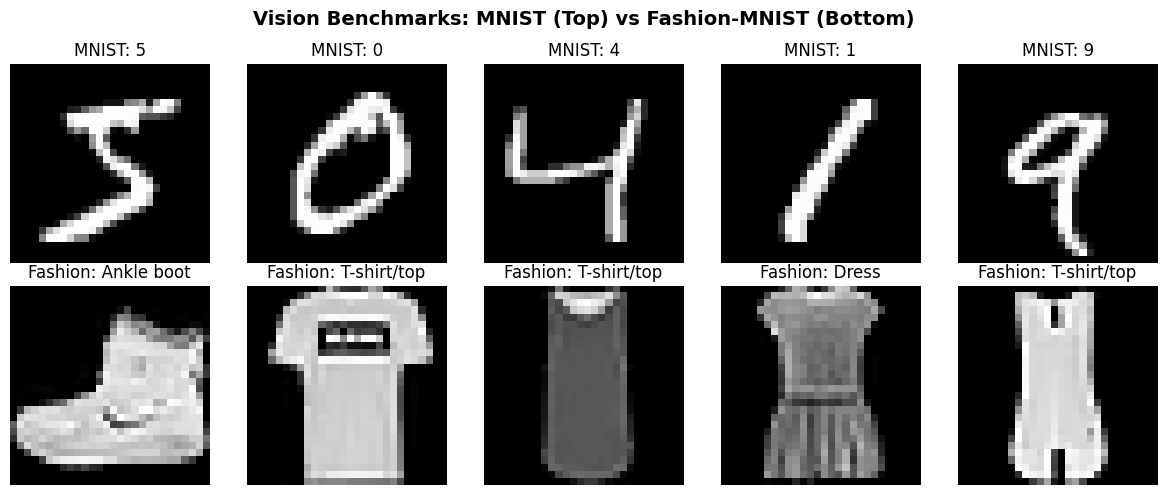

📊 ImageNet ILSVRC Top-1 vs Top-5 Error Rate Evaluation (N=1000, C=1000):
   1️⃣ Untrained Random Guessing Model:
      Top-1 Error Rate: 99.90%  (Expected: 100 - 0.1% = 99.9%)
      Top-5 Error Rate: 99.60%  (Expected: 100 - 0.5% = 99.5%)
   2️⃣ Trained ImageNet ConvNet / ResNet Model:
      Top-1 Error Rate: 16.80%  (Top-1 Accuracy: 83.20%)
      Top-5 Error Rate: 14.80%   (Top-5 Accuracy: 85.20%)


In [2]:
# Visualizing small vision benchmarks (MNIST & Fashion-MNIST)
transform = transforms.Compose([transforms.ToTensor()])

mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
fashion_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Vision Benchmarks: MNIST (Top) vs Fashion-MNIST (Bottom)", fontsize=14, fontweight='bold')

mnist_classes = [str(i) for i in range(10)]
fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(5):
    # MNIST
    img_m, label_m = mnist_dataset[i]
    axes[0, i].imshow(img_m.squeeze(), cmap='gray')
    axes[0, i].set_title(f"MNIST: {mnist_classes[label_m]}")
    axes[0, i].axis('off')

    # Fashion-MNIST
    img_f, label_f = fashion_dataset[i]
    axes[1, i].imshow(img_f.squeeze(), cmap='gray')
    axes[1, i].set_title(f"Fashion: {fashion_classes[label_f]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Code Demonstration of Top-1 vs Top-5 Error Rate Calculation
def compute_topk_errors(logits, targets, k=5):
    probs = F.softmax(logits, dim=-1)
    topk_preds = torch.topk(probs, k=k, dim=-1).indices # (N, k)

    targets_expanded = targets.unsqueeze(1).expand_as(topk_preds)
    top1_correct = (topk_preds[:, :1] == targets_expanded[:, :1]).sum().item()
    topk_correct = (topk_preds == targets_expanded).any(dim=1).sum().item()

    N = targets.size(0)
    top1_error = 1.0 - (top1_correct / N)
    topk_error = 1.0 - (topk_correct / N)
    return top1_error, topk_error

# Simulation over N=1000 samples and C=1000 classes
N_samples, C_classes = 1000, 1000
simulated_targets = torch.randint(0, C_classes, (N_samples,))

# Scenario A: Random Model Baseline (Pure Guessing)
random_logits = torch.randn(N_samples, C_classes)
rand_t1_err, rand_t5_err = compute_topk_errors(random_logits, simulated_targets, k=5)

# Scenario B: Trained ImageNet ResNet Model Simulation
trained_logits = torch.randn(N_samples, C_classes) * 1.5
# Add strong signal to true class for ~85% Top-1 / ~96% Top-5 accuracy
signal_mask = torch.rand(N_samples) < 0.85
for i in range(N_samples):
    if signal_mask[i]:
        trained_logits[i, simulated_targets[i]] += 8.0
    else:
        trained_logits[i, simulated_targets[i]] += torch.randn(1).item() * 2.0

trained_t1_err, trained_t5_err = compute_topk_errors(trained_logits, simulated_targets, k=5)

print("📊 ImageNet ILSVRC Top-1 vs Top-5 Error Rate Evaluation (N=1000, C=1000):")
print(f"   1️⃣ Untrained Random Guessing Model:")
print(f"      Top-1 Error Rate: {rand_t1_err * 100:.2f}%  (Expected: 100 - 0.1% = 99.9%)")
print(f"      Top-5 Error Rate: {rand_t5_err * 100:.2f}%  (Expected: 100 - 0.5% = 99.5%)")
print(f"   2️⃣ Trained ImageNet ConvNet / ResNet Model:")
print(f"      Top-1 Error Rate: {trained_t1_err * 100:.2f}%  (Top-1 Accuracy: {100 - trained_t1_err*100:.2f}%)")
print(f"      Top-5 Error Rate: {trained_t5_err * 100:.2f}%   (Top-5 Accuracy: {100 - trained_t5_err*100:.2f}%)")


## 2️⃣ Preprocessing Discrete Data: One-Hot Encoding & Feature Crosses

### 2.1 One-Hot Encoding Vector Space Representation
When a random variable $X$ is categorical and can take one of $K$ discrete values ($X \in \{1, 2, \dots, K\}$), feeding integer values ($1, 2, 3$) directly into linear models imposes a false metric distance ordering (e.g. implying $\text{American} > \text{African} > \text{Indian}$).

Instead, we map $X$ to a $K$-dimensional One-Hot Vector $\mathbf{x} = \text{one\_hot}(X) \in \{0, 1\}^K$:
$$\mathbf{x} = [x_1, x_2, \dots, x_K]^\top, \quad \text{where } x_k = \mathbb{I}(X = k) = \begin{cases} 1 & \text{if } X = k \\ 0 & \text{if } X \neq k \end{cases}$$

Properties of One-Hot Vectors:
1. Exact unit norm under $L_1$: \|\mathbf{x}\|_1 = \sum_{k=1}^K x_k = 1.
2. Orthogonality between distinct categories: $\mathbf{x}_i^\top \mathbf{x}_j = 0$ for $i \neq j$.

### 2.2 Feature Crosses (Nonlinear Interaction Terms)
A linear combination over independent one-hot features $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} = w_1 x_1 + w_2 x_2$ fails to capture interaction effects between variables. For example, a "Truck" produced in "India" may have a vastly different durability profile than a "Truck" produced in another country.

To capture multiplicative interaction without deep neural networks, we construct **Feature Crosses** (tensor outer-products of indicator variables):
$$\mathbf{c} = \mathbf{x}^{(1)} \otimes \mathbf{x}^{(2)}$$

For binary indicator features $x_i^{(1)} = \mathbb{I}(X_1 = i)$ and $x_j^{(2)} = \mathbb{I}(X_2 = j)$, the cross feature entry is:
$$c_{ij} = \mathbb{I}(X_1 = i \text{ AND } X_2 = j) = x_i^{(1)} \cdot x_j^{(2)}$$

The predictive model with feature crosses becomes:
$$f(X_1, X_2) = \sum_{i=1}^{K_1} w_i^{(1)} x_i^{(1)} + \sum_{j=1}^{K_2} w_j^{(2)} x_j^{(2)} + \sum_{i=1}^{K_1} \sum_{j=1}^{K_2} w_{ij}^{(1,2)} (x_i^{(1)} \cdot x_j^{(2)})$$


In [3]:
# Demonstrating One-Hot Encoding & Feature Crosses with Pandas & NumPy
data = pd.DataFrame({
    'VehicleType': ['Truck', 'Car', 'Truck', 'Car', 'Truck'],
    'OriginCountry': ['India', 'USA', 'Germany', 'India', 'USA']
})

print("📋 Raw Categorical Data:")
print(data)

# 1. One-Hot Encoding
ohe_vehicle = pd.get_dummies(data['VehicleType'], prefix='Vehicle')
ohe_country = pd.get_dummies(data['OriginCountry'], prefix='Country')

combined_ohe = pd.concat([ohe_vehicle, ohe_country], axis=1)
print("\n🔥 One-Hot Encoded Representation:")
print(combined_ohe)

# 2. Constructing Explicit Feature Crosses
feature_crosses = pd.DataFrame()
for v_col in ohe_vehicle.columns:
    for c_col in ohe_country.columns:
        cross_name = f"{v_col}_X_{c_col}"
        feature_crosses[cross_name] = ohe_vehicle[v_col] * ohe_country[c_col]

print("\n✖️ Feature Crosses Matrix (Capturing Interaction Effects):")
print(feature_crosses)


📋 Raw Categorical Data:
  VehicleType OriginCountry
0       Truck         India
1         Car           USA
2       Truck       Germany
3         Car         India
4       Truck           USA

🔥 One-Hot Encoded Representation:
   Vehicle_Car  Vehicle_Truck  Country_Germany  Country_India  Country_USA
0        False           True            False           True        False
1         True          False            False          False         True
2        False           True             True          False        False
3         True          False            False           True        False
4        False           True            False          False         True

✖️ Feature Crosses Matrix (Capturing Interaction Effects):
   Vehicle_Car_X_Country_Germany  Vehicle_Car_X_Country_India  \
0                          False                        False   
1                          False                        False   
2                          False                        False   
3  

## 3️⃣ Text Data Preprocessing & Vector Space Models

### 3.1 Three Core Challenges with Document Processing
1. **Variable Length Structure**: Unlike tabular datasets with fixed feature dimension $D$, documents $d_n$ contain variable number of tokens $T_n$.
2. **High-Cardinality Categorical Variables**: Words are discrete tokens sampled from a massive vocabulary $\mathcal{V}$ ($|\mathcal{V}| \ge 50,000$).
3. **Out-of-Vocabulary (OOV) Problem**: Open-class vocabulary implies test sets contain unseen words. Naive probabilistic models assign $P(w_{\text{unseen}}) = 0$.

### 3.2 Document Preprocessing Pipeline
1. **Punctuation & Stop-Word Removal**: Filtering non-informative high-frequency function words ("the", "is", "at").
2. **Stemming / Lemmatization**: Mapping morphological variants to canonical roots (e.g. $\text{running}, \text{runs} \to \text{run}$).

### 3.3 Bag-of-Words (BoW) & Term-Frequency Matrix
Let document $n$ be a sequence of tokens $(x_{n,1}, x_{n,2}, \dots, x_{n,T_n})$ where each $x_{n,t} \in \{1, \dots, D\}$ represents a token index in a vocabulary of size $D = |\mathcal{V}|$.

The count of word $v$ in document $n$ is defined via the indicator function:
$$\tilde{x}_{n, v} = \sum_{t=1}^{T_n} \mathbb{I}(x_{n,t} = v)$$

This transforms variable-length document $n$ into a fixed $D$-dimensional count vector:
$$\mathbf{\tilde{x}}_n = [\tilde{x}_{n,1}, \tilde{x}_{n,2}, \dots, \tilde{x}_{n,D}]^\top \in \mathbb{R}^D$$

Stacking $N$ documents yields the **Term Frequency (TF) Matrix** $\mathbf{TF} \in \mathbb{R}^{D \times N}$, where entry $\text{TF}_{i,j}$ represents the count of term $i$ in document $j$.

### 3.4 TF-IDF: Sublinear Scaling & Inverse Document Frequency
#### Why Sublinear Log Scaling?
Linear counts assume a word appearing 20 times is 20 times more important than a word appearing once. To suppress the undue influence of highly recurring words, we apply **Sublinear Log Scaling**:
$$\text{TF}_{i,j}^{\text{scaled}} = \log(1 + \text{TF}_{i,j})$$

#### Inverse Document Frequency (IDF)
Words occurring in almost every document (e.g. "document", "data") provide low discriminative signal. We penalize them using IDF:
$$\text{IDF}_i = \log\left(\frac{1 + N}{1 + \text{DF}_i}\right) + 1$$
where $\text{DF}_i = \sum_{j=1}^N \mathbb{I}(\text{TF}_{i,j} > 0)$ is the Document Frequency of term $i$.

The complete **TF-IDF Weight** is:
$$\text{TF-IDF}_{i,j} = \log(1 + \text{TF}_{i,j}) \times \left[\log\left(\frac{1 + N}{1 + \text{DF}_i}\right) + 1\right]$$


In [4]:
# Demonstrating Bag-of-Words vs TF-IDF Vectorization
corpus = [
    "Probabilistic machine learning models process text and image data.",
    "Machine learning algorithms optimize loss functions on data datasets.",
    "Text classification and machine translation are core natural language tasks."
]

# 1. Bag of Words (Raw Counts)
count_vectorizer = CountVectorizer(stop_words='english')
bow_matrix = count_vectorizer.fit_transform(corpus)
vocab = count_vectorizer.get_feature_names_out()

df_bow = pd.DataFrame(bow_matrix.toarray(), columns=vocab, index=[f"Doc {i+1}" for i in range(len(corpus))])
print("📊 Bag-of-Words (Term Count Matrix TF):")
print(df_bow.iloc[:, :8])

# 2. TF-IDF Matrix Computation
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vocab, index=[f"Doc {i+1}" for i in range(len(corpus))])
print("\n📈 TF-IDF Matrix (Sublinear Log-Scaled Importance):")
print(df_tfidf.iloc[:, :8].round(3))


📊 Bag-of-Words (Term Count Matrix TF):
       algorithms  classification  core  data  datasets  functions  image  \
Doc 1           0               0     0     1         0          0      1   
Doc 2           1               0     0     1         1          1      0   
Doc 3           0               1     1     0         0          0      0   

       language  
Doc 1         0  
Doc 2         0  
Doc 3         1  

📈 TF-IDF Matrix (Sublinear Log-Scaled Importance):
       algorithms  classification  core   data  datasets  functions  image  \
Doc 1       0.000            0.00  0.00  0.308     0.000      0.000  0.405   
Doc 2       0.392            0.00  0.00  0.298     0.392      0.392  0.000   
Doc 3       0.000            0.38  0.38  0.000     0.000      0.000  0.000   

       language  
Doc 1      0.00  
Doc 2      0.00  
Doc 3      0.38  


## 4️⃣ Continuous Word Embeddings, Document Embeddings & Subword Tokenization

### 4.1 Limitations of TF-IDF & The Need for Continuous Embeddings
TF-IDF vectors are orthogonal for distinct words: $\mathbf{e}_{\text{man}}^\top \mathbf{e}_{\text{woman}} = 0$. They fail to capture semantic proximity ($\text{man}$ should be close to $\text{woman}$, but far from $\text{banana}$).

In a continuous vector space $\mathbb{R}^K$ ($K \ll |\mathcal{V}|$), semantic similarity is measured via **Cosine Similarity**:
$$\text{Sim}(\mathbf{e}_1, \mathbf{e}_2) = \cos(\theta) = \frac{\mathbf{e}_1^\top \mathbf{e}_2}{\|\mathbf{e}_1\|_2 \|\mathbf{e}_2\|_2}$$

### 4.2 Mathematical Formalism of Bag of Word Embeddings
Let $\mathbf{E} \in \mathbb{R}^{K \times |\mathcal{V}|}$ be a learnable or pre-trained **Word Embedding Matrix**, where column $v$ contains the $K$-dimensional dense embedding vector $\mathbf{e}_v \in \mathbb{R}^K$ for word $v$.

For document $n$ represented by one-hot tokens $(\mathbf{x}_{n,1}, \dots, \mathbf{x}_{n,T_n})$, the document embedding $\mathbf{\bar{x}}_n \in \mathbb{R}^K$ is the mean word embedding:
$$\mathbf{\bar{x}}_n = \frac{1}{T_n} \sum_{t=1}^{T_n} \mathbf{E} \mathbf{x}_{n,t} = \frac{1}{T_n} \mathbf{E} \mathbf{\tilde{x}}_n$$

### 4.3 Classification & Parameter Estimation
Feeding document embedding $\mathbf{\bar{x}}_n$ into a Logistic Regression classifier yields class probabilities:
$$P(Y = c \mid \mathbf{\tilde{x}}_n; \mathbf{W}, \mathbf{E}) = \text{softmax}_c \left( \mathbf{W} \mathbf{\bar{x}}_n \right) = \frac{\exp\left( \mathbf{w}_c^\top \left( \frac{1}{T_n} \mathbf{E} \mathbf{\tilde{x}}_n \right) \right)}{\sum_{c'=1}^C \exp\left( \mathbf{w}_{c'}^\top \left( \frac{1}{T_n} \mathbf{E} \mathbf{\tilde{x}}_n \right) \right)}$$

- **Pre-trained Embeddings ($\mathbf{E}$ fixed)**: Optimization problem is convex and **linear in $\mathbf{W}$**.
- **Joint Training ($\mathbf{E}$ and $\mathbf{W}$ updated)**: Non-convex optimization (standard in modern Transformer LLMs).

### 4.4 Handling Novel Words: Subword Tokenization (BPE & WordPiece)
Instead of replacing unseen words with an `<UNK>` token (which discards semantic information), subword algorithms (e.g. Byte-Pair Encoding BPE, WordPiece) break rare/complex words into sub-morphemic units:
$$\text{"azagoraphobia"} \longrightarrow \text{["azagora", "##phobia"]}$$
The model leverages the root token `"phobia"` (fear) to infer semantic meaning for unknown compound words.


In [5]:
# PyTorch Implementation of Bag of Word Embeddings Classification
class BagOfWordsEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        # Embedding matrix E of shape (vocab_size, embed_dim)
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, mode='mean')
        # Linear classification head W
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, text, offsets):
        doc_embeds = self.embedding(text, offsets) # (Batch_Size, embed_dim)
        logits = self.fc(doc_embeds)               # (Batch_Size, num_classes)
        return logits

# Instantiate dummy model
V_size, K_dim, C_out = 1000, 16, 2
model = BagOfWordsEmbeddingClassifier(vocab_size=V_size, embed_dim=K_dim, num_classes=C_out)

# Dummy documents batch: doc 1 has 4 tokens, doc 2 has 3 tokens
text_tokens = torch.tensor([12, 45, 88, 9, 300, 12, 99], dtype=torch.long)
offsets = torch.tensor([0, 4], dtype=torch.long) # Starting indices of documents

logits = model(text_tokens, offsets)
probs = F.softmax(logits, dim=-1)

print("⚡ PyTorch Bag of Word Embeddings Output:")
print("   Document Embeddings Shape:", model.embedding(text_tokens, offsets).shape)
print("   Class Probabilities P(Y|X):\n", probs.detach().numpy().round(4))


⚡ PyTorch Bag of Word Embeddings Output:
   Document Embeddings Shape: torch.Size([2, 16])
   Class Probabilities P(Y|X):
 [[0.5099 0.4901]
 [0.4944 0.5056]]


## 5️⃣ Rubin's Missingness Mechanisms & Imputation Strategies

### 5.1 Formal Missingness Framework (Rubin, 1976)
Let $\mathbf{X} \in \mathbb{R}^{N \times D}$ be the full design matrix, partitioned into:
- **Observed Component $\mathbf{X}_v$ (or $\mathbf{X}_{\text{obs}}$)**: Features present in the dataset.
- **Hidden/Missing Component $\mathbf{X}_h$ (or $\mathbf{X}_{\text{mis}}$)**: Features missing from the dataset.

Let $\mathbf{M} \in \{0, 1\}^{N \times D}$ be the **Binary Missingness Indicator Matrix**:
$$M_{n,d} = \begin{cases} 1 & \text{if feature } d \text{ in sample } n \text{ is MISSING} \\ 0 & \text{if feature } d \text{ in sample } n \text{ is OBSERVED} \end{cases}$$

The conditional probability distribution of the missingness mechanism is $P(\mathbf{M} \mid \mathbf{X}_v, \mathbf{X}_h, \mathbf{Y})$.

---

### 5.2 The Three Missingness Taxonomies

#### 1. Missing Completely at Random (MCAR)
Missingness does NOT depend on observed features, missing features, or target labels:
$$P(\mathbf{M} \mid \mathbf{X}_v, \mathbf{X}_h, \mathbf{Y}) = P(\mathbf{M})$$
- *Example*: Lab sample tube accidentally dropped and broken on the floor.
- *Implication*: **Ignorable**. Deleting missing samples (complete-case analysis) or simple mean imputation introduces zero statistical bias.

#### 2. Missing at Random (MAR)
Missingness depends ONLY on observed data $\mathbf{X}_v$ and labels $\mathbf{Y}$, but is conditionally independent of missing values $\mathbf{X}_h$:
$$P(\mathbf{M} \mid \mathbf{X}_v, \mathbf{X}_h, \mathbf{Y}) = P(\mathbf{M} \mid \mathbf{X}_v, \mathbf{Y})$$
- *Example*: Younger survey participants ($\mathbf{X}_v$) are less likely to report income ($\mathbf{X}_h$).
- *Implication*: **Ignorable** if observed variables are controlled/conditioned on.

#### 3. Missing Not at Random (MNAR)
Missingness depends directly on the unobserved missing values $\mathbf{X}_h$ themselves:
$$P(\mathbf{M} \mid \mathbf{X}_v, \mathbf{X}_h, \mathbf{Y}) \text{ depends on } \mathbf{X}_h$$
- *Example*: Individuals with severe COVID symptoms ($\mathbf{X}_h$) are too ill to fill out an online health survey.
- *Implication*: **NON-IGNORABLE**. Ignoring the missingness mechanism produces severely biased parameter estimates. The missingness process $P(\mathbf{M} \mid \mathbf{X})$ MUST be explicitly modeled.

---

### 5.3 Imputation Techniques
1. **Mean Value Imputation**: Replaces missing entries in feature $d$ with the observed feature mean:
   $$\tilde{x}_{n,d} = \frac{1}{\sum_{i=1}^N (1 - M_{i,d})} \sum_{i: M_{i,d}=0} X_{i,d}$$
2. **Generative Model Imputation**: Fit a joint density $p(\mathbf{X})$ (e.g. Gaussian Mixture Model, EM Algorithm, VAE) and sample from conditional distribution $p(\mathbf{X}_h \mid \mathbf{X}_v)$.


In [6]:
# Simulating MCAR, MAR, and MNAR Data & Applying Imputation
np.random.seed(42)
N = 1000

# True complete data: Age ~ Normal(40, 10), Income = 1000 * Age + Normal(0, 5000)
age = np.random.normal(40, 10, N)
income = 1000 * age + np.random.normal(0, 5000, N)

df_complete = pd.DataFrame({'Age': age, 'Income': income})

# 1. Simulate MCAR (30% random missingness in Income)
mcar_mask = np.random.rand(N) < 0.3
df_mcar = df_complete.copy()
df_mcar.loc[mcar_mask, 'Income'] = np.nan

# 2. Simulate MAR (Income missing dependent on Age > 45)
mar_mask = (df_complete['Age'] > 45) & (np.random.rand(N) < 0.5)
df_mar = df_complete.copy()
df_mar.loc[mar_mask, 'Income'] = np.nan

# 3. Simulate MNAR (Income missing dependent on Income itself > 50,000)
mnar_mask = (df_complete['Income'] > 50000) & (np.random.rand(N) < 0.6)
df_mnar = df_complete.copy()
df_mnar.loc[mnar_mask, 'Income'] = np.nan

# Mean Imputation Evaluation
imputer = SimpleImputer(strategy='mean')
income_mcar_imp = imputer.fit_transform(df_mcar[['Income']])
income_mnar_imp = imputer.fit_transform(df_mnar[['Income']])

print("📊 Missingness Mechanism & Mean Imputation Bias Analysis:")
print(f"   True Population Mean Income:  ${df_complete['Income'].mean():,.2f}")
print(f"   MCAR Imputed Mean Income:    ${income_mcar_imp.mean():,.2f}  (Unbiased)")
print(f"   MNAR Imputed Mean Income:    ${income_mnar_imp.mean():,.2f}  (Severely Biased!)")


📊 Missingness Mechanism & Mean Imputation Bias Analysis:
   True Population Mean Income:  $40,547.50
   MCAR Imputed Mean Income:    $40,960.62  (Unbiased)
   MNAR Imputed Mean Income:    $38,416.69  (Severely Biased!)


## 6️⃣ AI Alignment, Reward Hacking & Inverse Reinforcement Learning

### 6.1 The Alignment Problem & Reward Hacking
In reinforcement learning and supervised reward optimization, we specify a scalar reward function $R(s, a)$ intended to encode human objectives.

**Reward Hacking** occurs when an ML agent optimizes the mathematical proxy $R(s, a)$ by discovering degenerate shortcuts that violate implicit human intent:
$$\max_{\pi} \mathbb{E}_{\pi} \left[ R(s, a) \right] \implies \text{Agent exploits missing specification constraints!}$$

### 6.2 Inverse Reinforcement Learning (IRL)
To tackle the alignment trap, Professor Stuart Russell proposed **Inverse Reinforcement Learning (IRL)**. Rather than hand-crafting $R(s, a)$, the agent observes optimal human trajectories $\mathcal{D}_{\text{human}} = \{(s_1, a_1), (s_2, a_2), \dots\}$ and infers the underlying reward function:
$$R^* = \arg\max_{R} P(\mathcal{D}_{\text{human}} \mid R)$$

*Caveat*: Learned reward functions risk overfitting to specific human biases or sub-optimal demonstrations.

### 6.3 AGI vs Augmented Intelligence
- **Artificial General Intelligence (AGI)**: Autonomous systems operating without human-in-the-loop oversight or feedback loops.
- **Augmented Intelligence**: AI systems designed to extend, assist, and enhance human decision-making processes.


In [7]:
# Summary Table of Core Concepts Covered in Lecture 4
summary_data = {
    "Concept": [
        "Small Vision Benchmarks",
        "ImageNet & Top-5 Error",
        "One-Hot Encoding",
        "Feature Crosses",
        "TF-IDF Vectorization",
        "Word Embeddings (E)",
        "Missingness (MCAR / MAR)",
        "Missingness (MNAR)",
        "Reward Hacking"
    ],
    "Mathematical Formulation": [
        "x_ij in [0, 255] -> normalize to [0, 1]",
        "P(y* not in S_{top-5}(x))",
        "x_k = I(X = k) in {0, 1}^K",
        "c_{ij} = x_i^(1) * x_j^(2)",
        "TF * log((1 + N) / (1 + DF))",
        "E in R^(K x |V|), e_bar = (1/T) E x_tilde",
        "P(M | X_v, X_h, Y) = P(M | X_v, Y)",
        "P(M | X_v, X_h, Y) depends on X_h",
        "max_pi E[R(s,a)] vs True Human Intent"
    ],
    "Practical Implication / Solution": [
        "Standardized baseline testing for computer vision",
        "Evaluates high-dimensional 1000-class probabilistic outputs",
        "Prevents false ordinal assumptions in linear models",
        "Captures feature interaction effects explicitly",
        "Suppresses non-informative frequent recurring words",
        "Captures continuous semantic similarity cos(theta)",
        "Ignorable missingness; mean/generative imputation valid",
        "NON-IGNORABLE; missingness mechanism MUST be modeled",
        "Inverse RL (learn reward from human demonstrations)"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("📌 Lecture 4 Master Concept & Methodological Summary:")
print(df_summary.to_string(index=False))


📌 Lecture 4 Master Concept & Methodological Summary:
                 Concept                  Mathematical Formulation                            Practical Implication / Solution
 Small Vision Benchmarks   x_ij in [0, 255] -> normalize to [0, 1]           Standardized baseline testing for computer vision
  ImageNet & Top-5 Error                 P(y* not in S_{top-5}(x)) Evaluates high-dimensional 1000-class probabilistic outputs
        One-Hot Encoding                x_k = I(X = k) in {0, 1}^K         Prevents false ordinal assumptions in linear models
         Feature Crosses                c_{ij} = x_i^(1) * x_j^(2)             Captures feature interaction effects explicitly
    TF-IDF Vectorization              TF * log((1 + N) / (1 + DF))         Suppresses non-informative frequent recurring words
     Word Embeddings (E) E in R^(K x |V|), e_bar = (1/T) E x_tilde          Captures continuous semantic similarity cos(theta)
Missingness (MCAR / MAR)        P(M | X_v, X_h, Y) = P(M |